<a href="https://colab.research.google.com/github/SammyBoi242006/CCPS_project/blob/main/notebooks/binary_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
PyTorch: 2.11.0+cu128
GPU: True
Device: cuda


In [2]:
PLANTVILLAGE = '/content/drive/MyDrive/project/data/plantvillage_tomato/PlantVillage'
RESULTS      = '/content/drive/MyDrive/project/results'
os.makedirs(RESULTS, exist_ok=True)

# Only these 3 classes for now
SELECTED_CLASSES = [
    'Tomato_healthy',
    'Tomato_Bacterial_spot',
    'Tomato_Early_blight'
]

CONFIG = {
    'image_size'  : 224,
    'batch_size'  : 32,
    'num_workers' : 2,
    'epochs'      : 10,
    'lr'          : 1e-4,
    'seed'        : 42,
    'mean'        : [0.485, 0.456, 0.406],
    'std'         : [0.229, 0.224, 0.225],
}

class_to_idx = {cls: idx for idx, cls in enumerate(SELECTED_CLASSES)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}

print("Classes:")
for cls, idx in class_to_idx.items():
    print(f"  {idx}: {cls}")

Classes:
  0: Tomato_healthy
  1: Tomato_Bacterial_spot
  2: Tomato_Early_blight


In [3]:
torch.manual_seed(CONFIG['seed'])

all_paths, all_labels = [], []

for cls in SELECTED_CLASSES:
    cls_path = os.path.join(PLANTVILLAGE, cls)
    for img_file in os.listdir(cls_path):
        if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_paths.append(os.path.join(cls_path, img_file))
            all_labels.append(class_to_idx[cls])

print(f"Total images loaded: {len(all_paths)}")
for idx, cls in idx_to_class.items():
    print(f"  {cls}: {all_labels.count(idx)}")

# Stratified split
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels, test_size=0.30,
    stratify=all_labels, random_state=CONFIG['seed']
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.50,
    stratify=temp_labels, random_state=CONFIG['seed']
)

print(f"\nTrain : {len(train_paths)}")
print(f"Val   : {len(val_paths)}")
print(f"Test  : {len(test_paths)}")

Total images loaded: 4718
  Tomato_healthy: 1591
  Tomato_Bacterial_spot: 2127
  Tomato_Early_blight: 1000

Train : 3302
Val   : 708
Test  : 708


In [4]:
train_transform = A.Compose([
    A.Resize(CONFIG['image_size'], CONFIG['image_size']),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=15, p=0.5),
    A.RandomResizedCrop(
        size=(CONFIG['image_size'], CONFIG['image_size']),
        scale=(0.8, 1.0), ratio=(0.9, 1.1), p=0.5
    ),
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1, p=0.5),
    A.RandomShadow(p=0.3),
    A.CoarseDropout(max_holes=8, max_height=20, max_width=20, p=0.3),
    A.GaussNoise(var_limit=(10, 50), p=0.3),
    A.MotionBlur(blur_limit=5, p=0.2),
    A.GaussianBlur(blur_limit=3, p=0.2),
    A.Normalize(mean=CONFIG['mean'], std=CONFIG['std']),
    ToTensorV2()
])

val_test_transform = A.Compose([
    A.Resize(CONFIG['image_size'], CONFIG['image_size']),
    A.Normalize(mean=CONFIG['mean'], std=CONFIG['std']),
    ToTensorV2()
])

print("Transforms ready.")

/tmp/ipykernel_668/204584386.py:12: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=20, max_width=20, p=0.3),
/tmp/ipykernel_668/204584386.py:13: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10, 50), p=0.3),


Transforms ready.


In [5]:
class TomatoDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img   = np.array(Image.open(self.paths[idx]).convert('RGB'))
        label = self.labels[idx]
        if self.transform:
            img = self.transform(image=img)['image']
        return img, label

train_dataset = TomatoDataset(train_paths, train_labels, train_transform)
val_dataset   = TomatoDataset(val_paths,   val_labels,   val_test_transform)
test_dataset  = TomatoDataset(test_paths,  test_labels,  val_test_transform)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 3302 | Val: 708 | Test: 708


In [6]:
class_counts    = Counter(train_labels)
class_weights   = {cls: 1.0 / count for cls, count in class_counts.items()}
sample_weights  = torch.tensor([class_weights[l] for l in train_labels], dtype=torch.float)
sampler         = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'],
                          sampler=sampler, num_workers=CONFIG['num_workers'], pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=CONFIG['batch_size'],
                          shuffle=False,  num_workers=CONFIG['num_workers'], pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=CONFIG['batch_size'],
                          shuffle=False,  num_workers=CONFIG['num_workers'], pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches  : {len(val_loader)}")
print(f"Test batches : {len(test_loader)}")

Train batches: 104
Val batches  : 23
Test batches : 23


In [7]:
class HybridModel(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        # CNN Branch — extracts local texture features
        self.cnn_branch = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                              # 112x112

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),                              # 56x56

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((7, 7))                  # 7x7
        )
        self.cnn_flat = nn.Flatten()
        self.cnn_fc   = nn.Linear(128 * 7 * 7, 256)

        # Transformer Branch — captures global context
        self.transformer = timm.create_model(
            'caformer_s18', pretrained=True,
            num_classes=0                                 # remove classifier head
        )
        transformer_out = self.transformer.num_features

        # Fusion — combine both branches
        self.classifier = nn.Sequential(
            nn.Linear(256 + transformer_out, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        # CNN path
        cnn_out = self.cnn_fc(self.cnn_flat(self.cnn_branch(x)))

        # Transformer path
        trans_out = self.transformer(x)

        # Fuse and classify
        fused = torch.cat([cnn_out, trans_out], dim=1)
        return self.classifier(fused)

model = HybridModel(num_classes=3).to(device)
print("Model built!")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/105M [00:00<?, ?B/s]

Model built!
Parameters: 25,135,155


In [8]:
# Weighted loss for class imbalance
counts       = [class_counts[i] for i in range(3)]
weights      = torch.tensor([1.0/c for c in counts], dtype=torch.float).to(device)
criterion    = nn.CrossEntropyLoss(weight=weights)

optimizer    = optim.Adam(model.parameters(), lr=CONFIG['lr'])
scheduler    = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

print("Loss, optimizer, scheduler ready.")

Loss, optimizer, scheduler ready.


In [10]:
train_losses, val_losses, val_accuracies = [], [], []

for epoch in range(CONFIG['epochs']):
    # Training
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    correct, total, val_loss = 0, 0, 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs  = model(images)
            val_loss += criterion(outputs, labels).item()
            preds    = outputs.argmax(dim=1)
            correct  += (preds == labels).sum().item()
            total    += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_acc      = correct / total * 100
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)
    scheduler.step()

    print(f"Epoch {epoch+1:02d}/{CONFIG['epochs']} | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Val Acc: {val_acc:.2f}%")

Epoch 01/10 | Train Loss: 0.3158 | Val Loss: 0.0174 | Val Acc: 99.58%
Epoch 02/10 | Train Loss: 0.0926 | Val Loss: 0.0426 | Val Acc: 98.59%
Epoch 03/10 | Train Loss: 0.0729 | Val Loss: 0.0157 | Val Acc: 99.29%
Epoch 04/10 | Train Loss: 0.0555 | Val Loss: 0.0108 | Val Acc: 99.44%
Epoch 05/10 | Train Loss: 0.0338 | Val Loss: 0.0294 | Val Acc: 99.44%
Epoch 06/10 | Train Loss: 0.0221 | Val Loss: 0.0006 | Val Acc: 100.00%
Epoch 07/10 | Train Loss: 0.0217 | Val Loss: 0.0013 | Val Acc: 100.00%
Epoch 08/10 | Train Loss: 0.0357 | Val Loss: 0.0006 | Val Acc: 100.00%
Epoch 09/10 | Train Loss: 0.0229 | Val Loss: 0.0015 | Val Acc: 99.86%
Epoch 10/10 | Train Loss: 0.0181 | Val Loss: 0.0073 | Val Acc: 99.86%


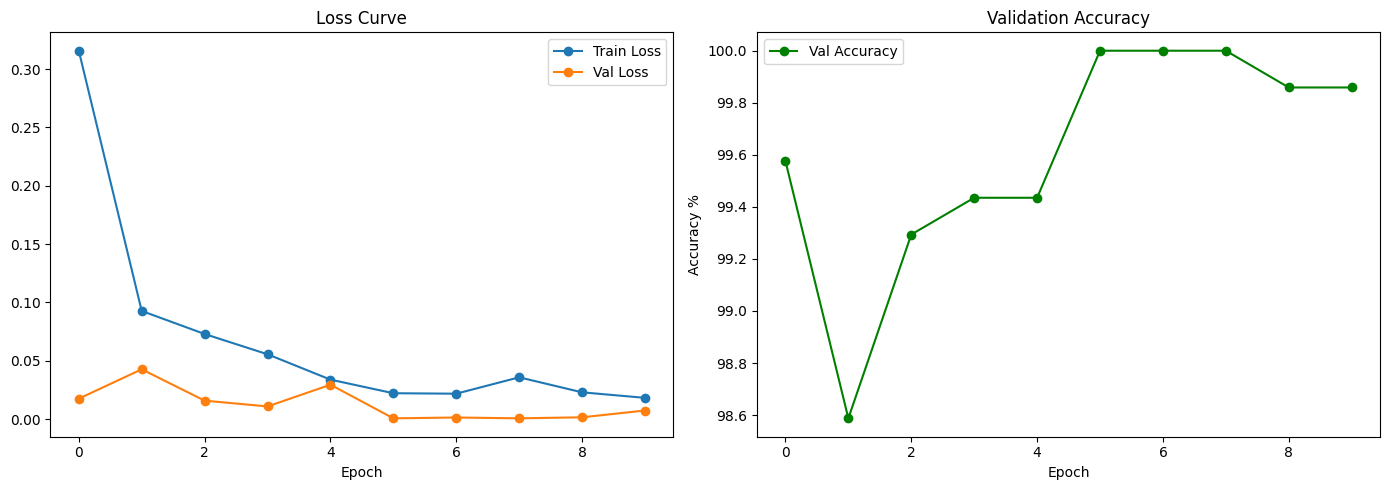

Saved!


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Train Loss', marker='o')
ax1.plot(val_losses,   label='Val Loss',   marker='o')
ax1.set_title('Loss Curve')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(val_accuracies, label='Val Accuracy', marker='o', color='green')
ax2.set_title('Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy %')
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'binary_training_curves.png'), dpi=150)
plt.show()
print("Saved!")

                       precision    recall  f1-score   support

       Tomato_healthy       1.00      1.00      1.00       239
Tomato_Bacterial_spot       1.00      1.00      1.00       319
  Tomato_Early_blight       1.00      1.00      1.00       150

             accuracy                           1.00       708
            macro avg       1.00      1.00      1.00       708
         weighted avg       1.00      1.00      1.00       708



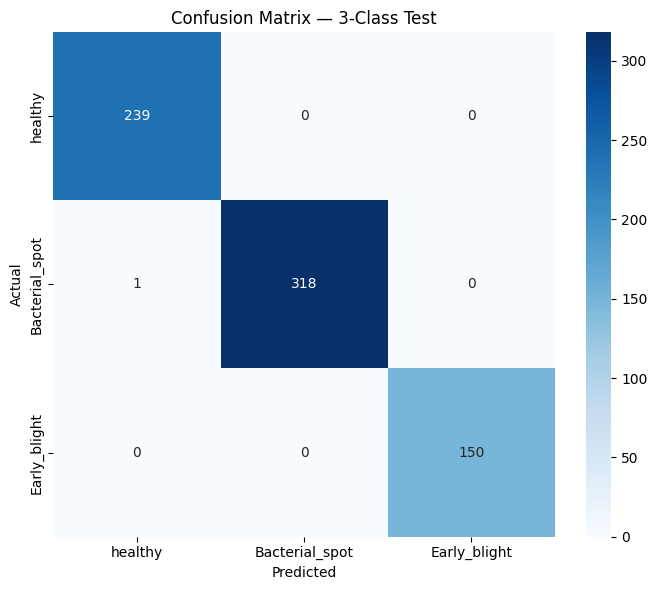

In [12]:
model.eval()
all_preds, all_labels_list = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        preds  = model(images).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels_list.extend(labels.numpy())

# Classification report
print(classification_report(
    all_labels_list, all_preds,
    target_names=[idx_to_class[i] for i in range(3)]
))

# Confusion matrix
cm = confusion_matrix(all_labels_list, all_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[idx_to_class[i].replace('Tomato_','') for i in range(3)],
            yticklabels=[idx_to_class[i].replace('Tomato_','') for i in range(3)])
plt.title('Confusion Matrix — 3-Class Test')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'binary_confusion_matrix.png'), dpi=150)
plt.show()

In [13]:
save_path = '/content/drive/MyDrive/project/models/binary_model.pth'
os.makedirs(os.path.dirname(save_path), exist_ok=True)

torch.save({
    'model_state_dict' : model.state_dict(),
    'class_to_idx'     : class_to_idx,
    'config'           : CONFIG,
}, save_path)

print(f"Model saved to {save_path}")

Model saved to /content/drive/MyDrive/project/models/binary_model.pth
